In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [16]:
training = pd.read_csv('train.csv')

test  = pd.read_csv('test.csv')

training.columns

Index(['id', 'brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

# **Explanatory Data Analysis**

In [17]:
#things to consider
#model_year
#accident
#clean_title
training.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


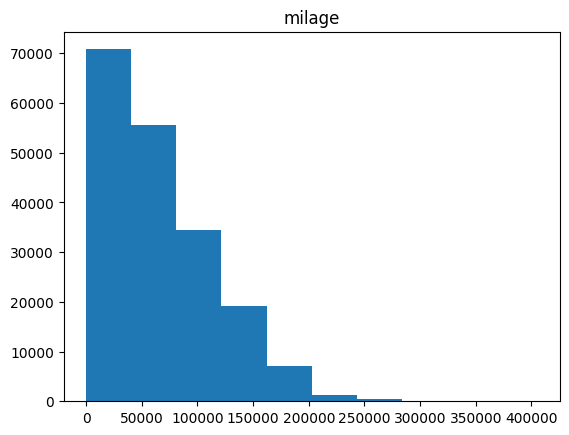

In [18]:
plt.hist(training['milage'])
plt.title('milage')
plt.show()

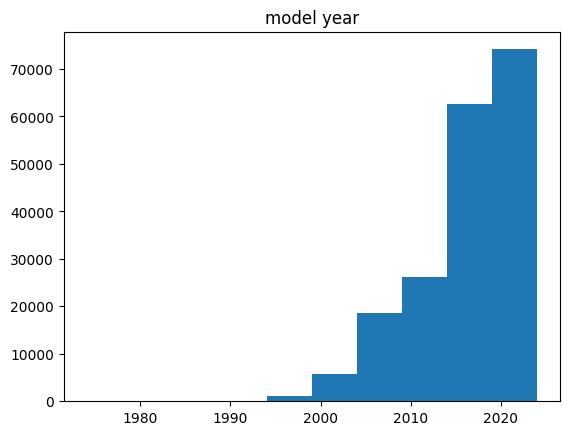

In [19]:
plt.hist(training['model_year'])
plt.title('model year')
plt.show()

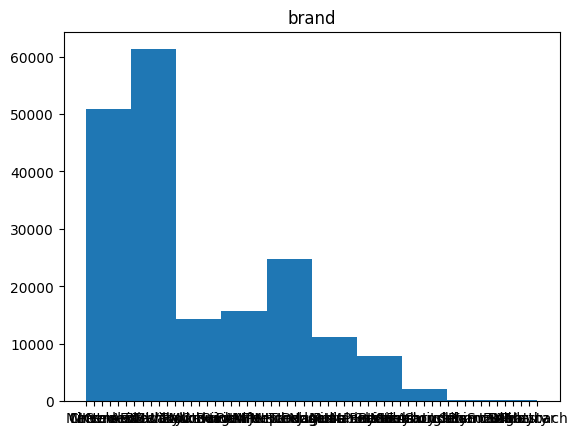

In [20]:
plt.hist(training['brand'])
plt.title('brand')
plt.show()

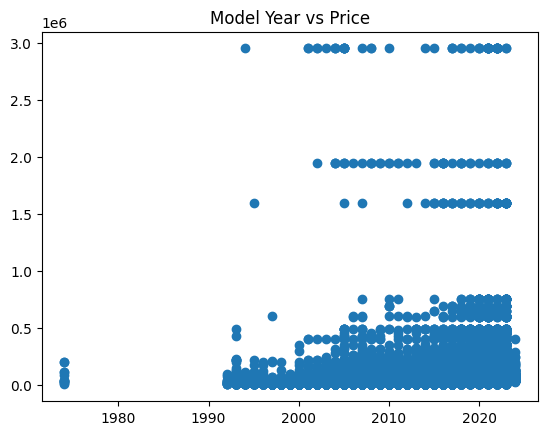

In [21]:
plt.scatter(training['model_year'], training['price'])
plt.title('Model Year vs Price')
plt.show()

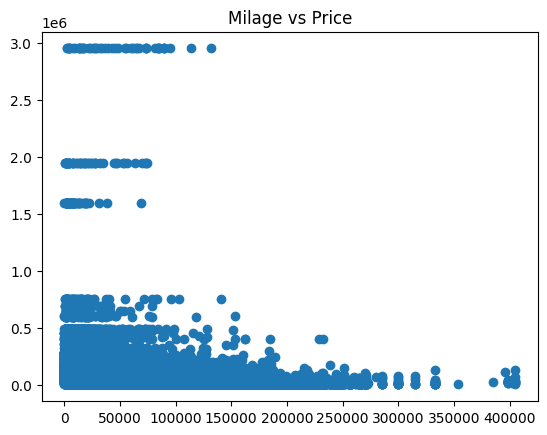

In [22]:
plt.scatter(training['milage'], training['price'])
plt.title('Milage vs Price')
plt.show()

              milage  model_year     price
milage      1.000000   -0.669936 -0.283067
model_year -0.669936    1.000000  0.231795
price      -0.283067    0.231795  1.000000


<Axes: >

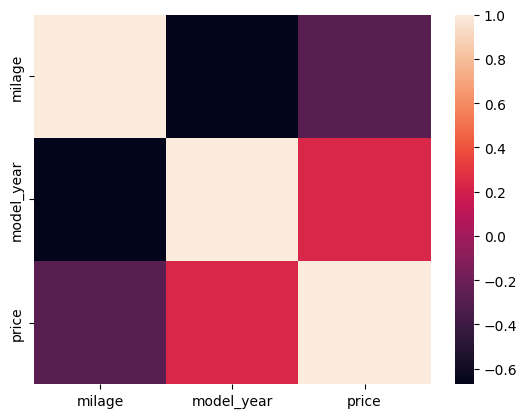

In [23]:
df_models = training[['milage', 'model_year', 'price']]
print(df_models.corr())
sns.heatmap(df_models.corr())

In [24]:
training.isnull().sum()

id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        5083
engine              0
transmission        0
ext_col             0
int_col             0
accident         2452
clean_title     21419
price               0
dtype: int64

# **Data Preprocessing**

In [25]:
training['fuel_type'] = training.groupby('brand')['fuel_type'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))
training['accident'] = np.where(
    (training['accident'].isna()) & (training['clean_title'] == 'Yes'),
    'None Reported',
    training['accident']
)

training['accident'] = np.where(
    (training['accident'].isna()) & (training['clean_title'] == 'No'),
    'At least 1 accident or damage reported',
    training['accident']
)

training['accident'] = np.where(
            (training['accident'].isna()) & (training['clean_title'].isna()),
            'Unknown',  # Or 'Missing Clean Title'
            training['accident']
        )
training['clean_title'].fillna('Unknown', inplace=True)

training = training.drop(columns='id')

training.isnull().sum()

C:\Users\veena\AppData\Local\Temp\ipykernel_32552\2394266186.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  training['clean_title'].fillna('Unknown', inplace=True)


brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

# **Training and Testing Data Using Random Forest Regressor**

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Drop duplicates
training.drop_duplicates(inplace=True)

# Separate features and target
#X = training[numerical_cols + categorical_cols]
X = training.drop(columns='price')
Y = np.log1p(training['price'])
# After prediction, use: np.expm1(y_pred)


# Define categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Define transformers
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Create pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=5))
])




# Fit the pipeline
pipeline.fit(X_train, Y_train)

# Predict and evaluate
y_pred = pipeline.predict(X_test)
#y_pred_original = np.expm1(y_pred)

# Convert Y_test as well
#Y_test_original = np.expm1(Y_test)

# Now calculate MSE
mse = mean_squared_error(Y_test, y_pred)


#print("Mean Squared Error (original scale):", mse)
#print(f"R² Score (original scale): {r2:.2f}")
tolerance = 0.10
within_tolerance = np.abs((y_pred - Y_test) / Y_test) <= tolerance
regression_accuracy = np.mean(within_tolerance)

# R² Score
r2 = r2_score(Y_test, y_pred)

print("Mean Squared Error:", mse)
print(f"R² Score: {r2:.2f}")
print(f"Regression Accuracy (within ±10%): {regression_accuracy:.2%}")

Mean Squared Error: 0.27779744437287573
Regression Accuracy (within ±10%): 94.35%
R² Score: 0.61


# **Feature Importance**

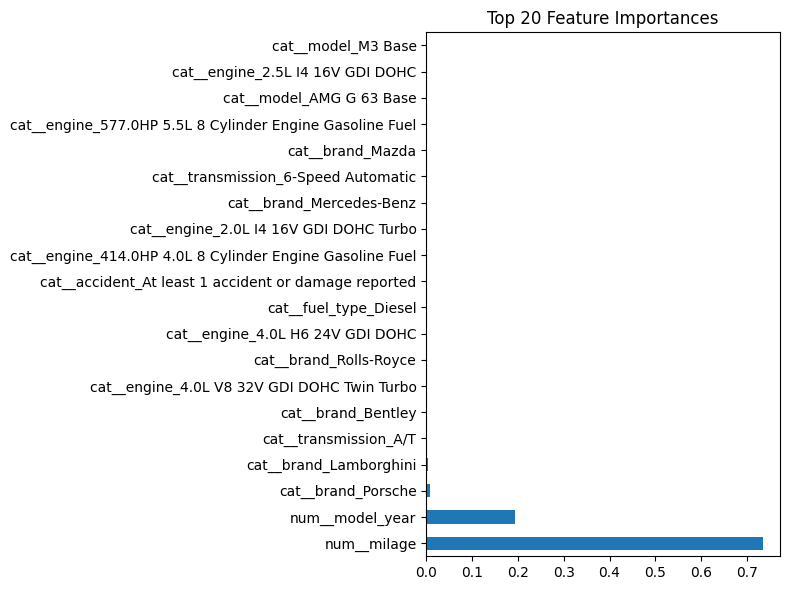

In [27]:
importances = pipeline.named_steps['regressor'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feat_imp.head(20).plot(kind='barh', figsize=(8,6))
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

# **Predict Prices Using Test Data**

In [28]:
# Ensure test data has the same features as training
X_test_final = test[X.columns]  # uses same columns as training (excluding 'price')

# Predict in log space
y_pred_log = pipeline.predict(X_test_final)

# Convert back from log scale
y_pred = np.expm1(y_pred_log)

# Create submission
submission = pd.DataFrame({
    'id': test['id'],
    'price': y_pred
})

#submission.to_csv('submission.csv', index=False)
submission.head()

,id,price
0,188533,18281.690541
1,188534,55364.645770
2,188535,49910.494596
3,188536,26395.427669
4,188537,35344.996473


# **Testing and Training Data Using XGBoost Regressor**

In [33]:
from xgboost import XGBRegressor

# Drop duplicates
training.drop_duplicates(inplace=True)

# Define target and features
X = training.drop(columns='price')
Y = np.log1p(training['price'])

# Column types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Preprocessing
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_model)
])

# Fit
pipeline.fit(X_train, Y_train)

# Predict and evaluate
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)
tolerance = 0.10
within_tolerance = np.abs((y_pred - Y_test) / Y_test) <= tolerance
regression_accuracy = np.mean(within_tolerance)

print("MSE (log scale):", mse)
print(f"R² Score: {r2:.2f}")
print(f"Regression Accuracy (±10%): {regression_accuracy:.2%}")


MSE (log scale): 0.2533603255348427
R² Score: 0.65
Regression Accuracy (±10%): 95.01%


# **Feature Importances**

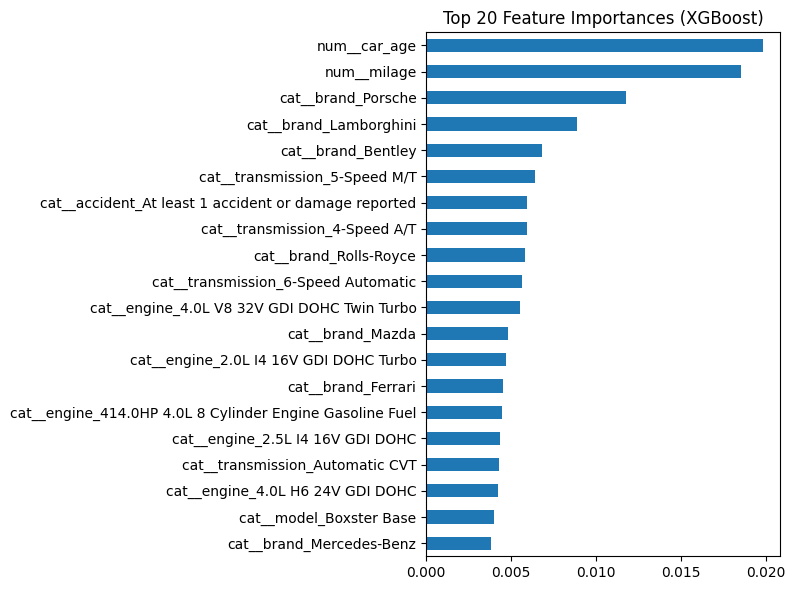

In [34]:
importances = pipeline.named_steps['regressor'].feature_importances_

# Get feature names from the preprocessor
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Create a pandas Series for sorting and plotting
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot top 20 features
plt.figure(figsize=(8, 6))
feat_imp.head(20).plot(kind='barh')
plt.title("Top 20 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# **Predict Prices using Test Data**

In [35]:
X_test_final = test[X.columns]
y_pred_log = pipeline.predict(X_test_final)
y_pred = np.expm1(y_pred_log)

submission = pd.DataFrame({
    'id': test['id'],
    'price': y_pred
})
submission.to_csv('submission_xgb.csv', index=False)
submission.head()

,id,price
0,188533,16280.944336
1,188534,60807.324219
2,188535,49000.085938
3,188536,25602.298828
4,188537,31349.585938
